In [ ]:
%conda install -c conda-forge scikit-learn

In [6]:
# 머신러닝
#지도학습(정답이 있음)
    # 분류(Classfication) , 회귀(Regression)
#비지도학습(정답이 없음)
    # 클러스터링 , 군집
#강화학습
#딥러닝 - 신경망

#EDA(탐색적 데이터분석) - 모델 - 추론
    #데이터 전처리 -
        # 이상치 제거 , 결측치 제거 , 피처 생성
        # 상관지수를 통한 적절한 변수 선택
    # 적절한 모델 선택
    # 평가
    # 추론


In [1]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

In [16]:
x = np.array([1,2,3,4]).reshape(-1,1)
y = np.array([55,45,65,75])

model = LinearRegression()
model.fit(x,y)

print(f'기울기 : {model.coef_}')
print(f'절편 : {model.intercept_}')

new_x = np.array([17,22,16,33]).reshape(-1,1)
print(f'새로운 데이터 : {model.predict(new_x)}')

기울기 : [8.]
절편 : 40.0
새로운 데이터 : [176. 216. 168. 304.]


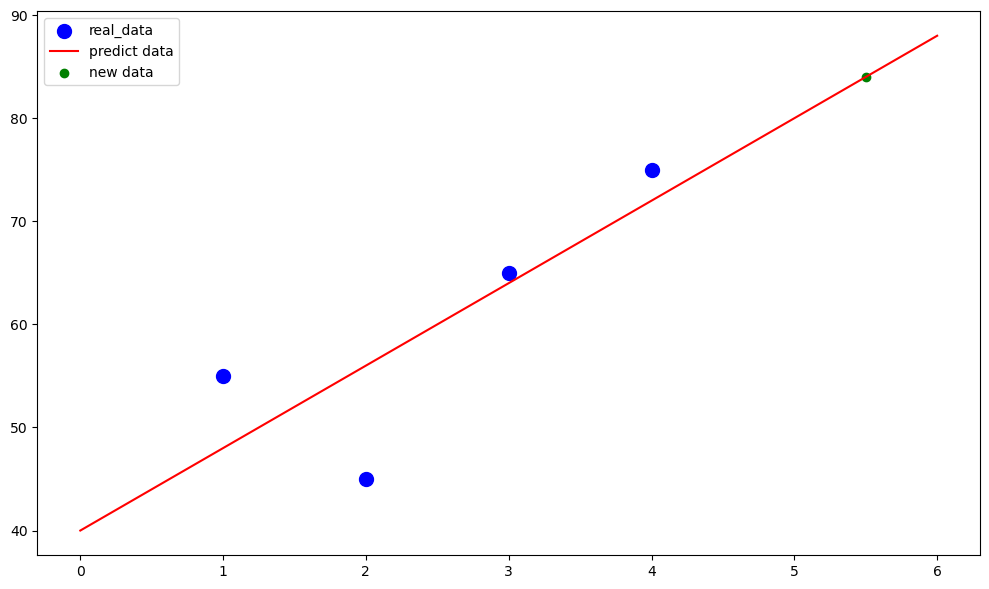

In [ ]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(10,6))
ax.scatter(x,y,color='blue' , s=100 , label='real_data')

x_line = np.linspace(0,6,100).reshape(-1,1)
y_line = model.predict(x_line)

ax.plot(x_line,y_line,color='red',label='predict data')

new_x = np.array([[5.5]])
new_y = model.predict(new_x)
ax.scatter(new_x,new_y,color='green',label='new data')

plt.legend()
plt.tight_layout()
plt.show()

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
load_diabetes(as_frame=True).frame

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# 정규화 : 각 원소를 평균으로 뺀 값을 표준편차로 나눔
import numpy as np

data = np.array([10,20,30])
data.mean() , data.std()

std_data = (data - data.mean()) / data.std()
std_data.mean() , round(std_data.std(),1)

(np.float64(0.0), np.float64(1.0))

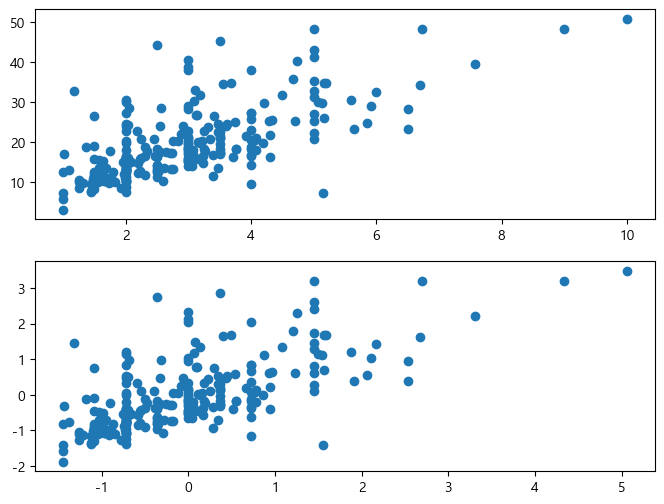

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')
fig,ax=plt.subplots(2,1,figsize=(8,6))

ax[0].scatter(tips['tip'] , tips['total_bill'])

standard_tip = (tips['tip'] - tips['tip'].mean()) / tips['tip'].std()
standard_total_bill = (tips['total_bill'] - tips['total_bill'].mean()) / tips['total_bill'].std()

ax[1].scatter(standard_tip ,standard_total_bill)

In [152]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
import numpy as np

df = load_diabetes(as_frame=True).frame
df.head()

x = df[['bmi']]
y = df['target']
print(x.shape , y.shape)

model = LinearRegression()
# 모델 선택 -> 모델 학습 -> 모델 예측(추론)
model.fit(x,y)
predict = model.predict(np.array([[0.06196]]))
print(predict)

(442, 1) (442,)
[210.9604929]


c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [211]:
import random
random_index = random.sample(range(442),442)
x2 = x['bmi'][random.sample(range(442),442)]
y2 = y[random_index]

split_count = int(len(x['bmi']) * 0.8)
x2_train = x2[:split_count]
y2_train = y2[:split_count]

x2_test = x2[split_count :]
y2_test = y2[split_count :]

model = LinearRegression()
model.fit(x2_train.to_numpy().reshape(-1,1) , y2_train)
predict = model.predict(x2_test.to_numpy().reshape(-1,1))
predict[:5] , y2_test[:5].to_numpy()

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
mean_absolute_error(y2_test , predict) , mean_squared_error(y2_test,predict) ** 0.5 , r2_score(y2_test,predict)

(64.01082285188377, 75.051103194764, -0.002651781688863153)

In [ ]:
# 데이터 (x,y)
# 데이터를 섞어서 분할(학습용과 테스트용)
# 적절한 모델 선택
# 학습 -> 학습용 데이터
# 추론() -> 테스트용 데이터
# 평가 : 테스트용데이터의 실제 정답 vs 모델이 테스트용 데이터로 예측한 값의 오차

In [ ]:
from sklearn.model_selection import train_test_split

x = df[['bmi', 'bp']].values
y = df['target'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train,y_train) 
predicted = model.predict(x_test)
mean_absolute_error(y_test , predicted) , mean_squared_error(y_test,predicted) ,r2_score(y_test,predicted)

(45.92221163528518, 3112.711413953739, 0.5070859188103449)

In [265]:
y = np.array([1,2,3,4])
y_hat = np.array([10,10,10,10])

y_mean = y.mean()
# SS_tot 데이터 자체의 변동성 , 데이터의 퍼짐 정도
SS_tot = sum((y - y_mean)**2)
# SS_res 모델 오차
SS_res = sum((y-y_hat)**2)
# 결정계수   1 - SSres / SStot
print(f'결정계수 {1 - SS_res / SS_tot}')
print(f'전체변동 : {SS_tot}')
print(f'모델이 못 맞춘 부분 : {SS_res}')
print(f'모델이 설명한 부분 : {SS_tot - SS_res}')


결정계수 -45.0
전체변동 : 5.0
모델이 못 맞춘 부분 : 230
모델이 설명한 부분 : -225.0


In [269]:
# 데이터 , 데이터 분리(훈련데이터 , 평가데이터) , 학습(훈련데이터) , 평가(평가용데이터) --> 평가함수를통해 성능을 지표로 표현
# 1. 데이터로드
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

feature_cols = ['bmi' , 'bp']
x = df[feature_cols]
y = df['target']

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=40)
# 파이프라인구성 (전처리(스케일링) 과 선형회귀를 묶어)
pipeline = Pipeline(steps=[
    ('scaler' , StandardScaler()) , ('model' , LinearRegression())
])
pipeline.fit(x_train , y_train)
y_pred = pipeline.predict(x_test)
print(r2_score(y_test , y_pred))

0.31709000017431


In [ ]:
# 선형회귀
# 데이터분할
# 모델평가 지표 ( 결정계수 , 평균제곱오차 , 평균절대오차)
# 파이프라인

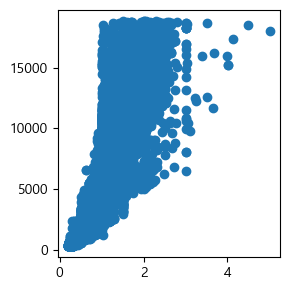

In [ ]:
# 정규화
df = sns.load_dataset('diamonds')
fig,ax=plt.subplots(figsize=(3,3))
ax.scatter(df['carat'] , df['price'])

plt.tight_layout()
plt.show()

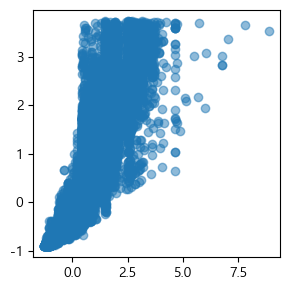

In [286]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
fig,ax=plt.subplots(figsize=(3,3))
ax.scatter(s.fit_transform(df[['carat']]),
           s.fit_transform(df[['price']]),
           alpha=0.5
           )
plt.tight_layout()
plt.show()

In [296]:
# 데이터 (x,y)
# 데이터를 섞어서 분할(학습용과 테스트용)
# 적절한 모델 선택
# 학습 -> 학습용 데이터
# 추론() -> 테스트용 데이터
# 평가 : 테스트용데이터의 실제 정답 vs 모델이 테스트용 데이터로 예측한 값의 오차
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

x = df[['carat', 'depth' , 'table']].values
y = df['price'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , random_state=100)

model = LinearRegression()
model.fit(x_train,y_train)
predicted = model.predict(x_test)
mean_absolute_error(y_test , predicted) , mean_squared_error(y_test,predicted) ** 0.5 ,r2_score(y_test,predicted)

(987.6754068880058, 1519.8708631049692, 0.8517943055287095)

In [304]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # 규칙을 적용하고 적용한 규칙기반으로 데이터를 변환
x_test_scaled = scaler.transform(x_test)  # 이미 적용된 규칙으로 변환함

model = LinearRegression()
model.fit(x_train_scaled , y_train)
y_scaled_predict = model.predict(x_test_scaled)

mean_absolute_error(y_test , y_scaled_predict) , mean_squared_error(y_test, y_scaled_predict) ** 0.5 ,r2_score(y_test, y_scaled_predict)

(987.6754068880023, 1519.870863104968, 0.8517943055287097)

In [310]:
from lightgbm import LGBMRegressor

df = sns.load_dataset('diamonds')
x = df[['carat', 'depth' , 'table']].values
y = df['price'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , random_state=15)

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('model' , LGBMRegressor())
])

pipeline.fit(x_train,y_train)
y_predict = pipeline.predict(x_test)
mean_absolute_error(y_test , y_predict) , mean_squared_error(y_test, y_predict) ** 0.5 ,r2_score(y_test, y_predict)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 494
[LightGBM] [Info] Number of data points in the train set: 43152, number of used features: 3
[LightGBM] [Info] Start training from score 3928.826613


c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


(772.759975786745, 1364.3048468744473, 0.8838209154373401)